## Del A

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# lagrer navnet for lettere tilbakekalling senere
file = "support_uke_24.xlsx"

# leser inn data fra excel filen og sjekker output
df = pd.read_excel(file)
print(df)

# Tildele variablene til de ulike kolonnene
u_dag = np.array(df["Ukedag"])
k_slett = np.array(df["Klokkeslett"])
varighet = np.array(df["Varighet"])
score = np.array(df["Tilfredshet"])


     Ukedag Klokkeslett  Varighet  Tilfredshet
0    Mandag    08:04:16  00:07:12          NaN
1    Mandag    08:04:53  00:02:49          6.0
2    Mandag    08:06:31  00:08:36          NaN
3    Mandag    08:11:21  00:04:34          NaN
4    Mandag    08:20:46  00:07:38          NaN
..      ...         ...       ...          ...
212  Fredag    15:06:52  00:11:12          NaN
213  Fredag    15:25:32  00:10:21          NaN
214  Fredag    15:30:39  00:07:16          NaN
215  Fredag    15:39:11  00:08:49          NaN
216  Fredag    15:56:10  00:10:13         10.0

[217 rows x 4 columns]


## Del B

In [ ]:
# lagre tuppel output i to  variabler og teller sammen antall ulike dager
dager, antall = np.unique(u_dag, return_counts=True)

# sjekke resultat
print(dager)
print(antall)




['Fredag' 'Mandag' 'Onsdag' 'Tirsdag' 'Torsdag']
[42 51 45 44 35]


In [4]:
# Siden dagene var ikke i rekkefølge lager jeg en egen liste med riktig rekkefølge,
# og teller alt på nytt

# Sortere dagene manuelt for plotting
dager_rekkefølge = ["Mandag", "Tirsdag", "Onsdag", "Torsdag", "Fredag"]

# lage en tom liste hvor jeg kan tildele antall henvendelser til dagene i rekkefølge
antall_sortert = []

# løkke som teller opp antall henvendelser for dagene i den bestemte rekkefølgen
for dag in dager_rekkefølge:
    telling = np.sum(u_dag == dag)
    antall_sortert.append(telling)  # legge til antallet i samme rekkefølge i den tomme lista

print(antall_sortert)



[np.int64(51), np.int64(44), np.int64(45), np.int64(35), np.int64(42)]


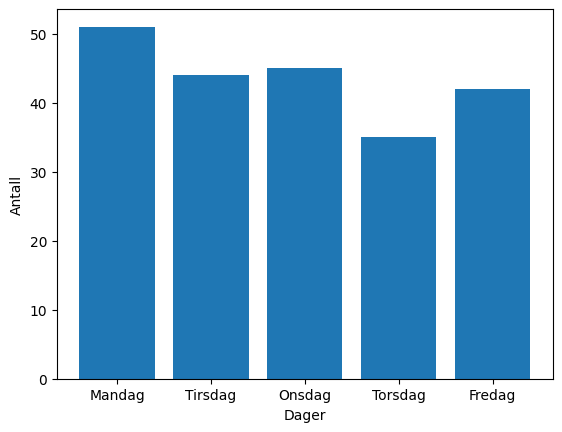

In [5]:
# Visualisering av antall dager i søylediagram
def plotting(dager, antall):
    plt.bar(dager, antall)
    plt.xlabel("Dager")
    plt.ylabel("Antall")
    plt.show()

plotting(dager_rekkefølge, antall_sortert)


## Del C

In [9]:
# finne den korteste og lengste samtaletiden og gi informativ tekst
korteste = min(varighet)
lengste = max(varighet)

# Gi en output i konsollen med informativ tekst om varighet
print("Den korteste samtalen var", korteste, "lang, og den lengste varte", lengste, ".")


Den korteste samtalen var 00:00:59 lang, og den lengste varte 00:11:28 .


## Del D

In [ ]:
# konvertere tiden til sekunder for lettere håndtering

# beregne deltaen for konvertering
delta_tid = pd.to_timedelta(varighet)
print(delta_tid)

# selve konverteringen til sekunder
sekunder = delta_tid.total_seconds()
print(sekunder)

TimedeltaIndex(['0 days 00:07:12', '0 days 00:02:49', '0 days 00:08:36',
                '0 days 00:04:34', '0 days 00:07:38', '0 days 00:02:56',
                '0 days 00:09:46', '0 days 00:06:47', '0 days 00:05:45',
                '0 days 00:11:17',
                ...
                '0 days 00:02:04', '0 days 00:08:44', '0 days 00:02:34',
                '0 days 00:05:06', '0 days 00:02:32', '0 days 00:11:12',
                '0 days 00:10:21', '0 days 00:07:16', '0 days 00:08:49',
                '0 days 00:10:13'],
               dtype='timedelta64[us]', length=217, freq=None)
Index([432.0, 169.0, 516.0, 274.0, 458.0, 176.0, 586.0, 407.0, 345.0, 677.0,
       ...
       124.0, 524.0, 154.0, 306.0, 152.0, 672.0, 621.0, 436.0, 529.0, 613.0],
      dtype='float64', length=217)


In [ ]:
# summere sekundene og beregne snit
total_tid = sum(sekunder)
snitt_tid = total_tid / len(varighet)

# Printe ut resultatene og runde av tallene
print(
    "Gjennomsnitlig tid for en samtale i perioden var:", round(snitt_tid, 2), " sekunder,som tilsvarer:", 
    round(snitt_tid / 60, 2), " minutter."
    )

## Del E

In [11]:
# beregne delta tiden for kl_slett
kl_slett_td = pd.to_timedelta(k_slett)

# Hente ut timene fra de ulike tidspunktene for henvendelsene
timer = kl_slett_td.components["hours"]

print(timer)

0       8
1       8
2       8
3       8
4       8
       ..
212    15
213    15
214    15
215    15
216    15
Name: hours, Length: 217, dtype: int64


In [ ]:
# en liste med navnene som jeg skal bruke i kakediagrammet
bolker_navn = ["kl 08-10", "kl 10-12", "kl 12-14", "kl 14-16"]

# lage en tom liste hvor jeg summerer opp antall observasjoner i bolkene som er definert i lista "grenser"
bolker = []
grenser = [(8,10), (10,12), (12,14), (14,16)]

# løkke for å telle sammen henvendelser i bolkene
for start, slutt in grenser:
    telling = np.sum((timer >= start) & (timer < slutt))
    bolker.append(telling)
    
# Sjekke antall observasjoner i de fire bolkene
print(bolker)

[np.int64(98), np.int64(40), np.int64(45), np.int64(34)]


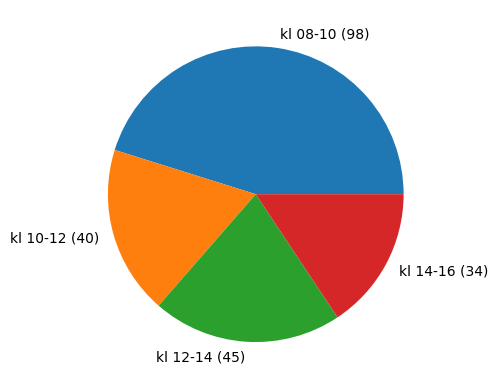

In [13]:
# Lager en dynamisk labeling system hvis det er endring i dataen

# bruker samme logikk som over ved å lage tom liste som jeg fyller opp med labels
labels = []

# zippe sammen tuppelsene for å enklere legge de til i kakediagrammet
for navn, antall in zip(bolker_navn, bolker):
    labels.append(f"{navn} ({antall})")

# plotte selve kakediagrammet
plt.pie(bolker, labels=labels)
plt.show()


## Del F

In [ ]:
print(score)

# Telle sammen antall detractors (score ≤ 6)
detractors = np.count_nonzero(score <= 6)
print(detractors)

# Telle sammen antall promoters (score 9 ≤ )
promoters = np.count_nonzero(score >= 9)
print(promoters)

# Telle sammen antall ikke-nan verdier i arrayen
antall_tilbakemelding = np.count_nonzero(~np.isnan(score))
print(antall_tilbakemelding)

[nan  6. nan nan nan  8. nan nan 10. nan nan nan nan nan nan nan  8. nan
 nan nan nan nan nan  9. nan nan nan 10. nan 10. nan nan nan nan nan nan
 nan nan  9. 10. nan nan nan nan nan nan  3.  3. nan 10. nan nan nan nan
 nan nan nan nan  9.  9. nan nan nan nan nan nan nan nan  9. nan 10. nan
 nan nan nan 10. nan nan nan nan nan nan nan nan nan  5. nan nan nan nan
 nan 10. nan nan nan nan nan nan 10. 10. nan nan nan nan nan nan nan nan
  1.  9. nan nan  1. nan 10. nan nan nan  5. nan nan nan nan nan nan nan
 nan  7. nan  9. nan nan nan nan nan nan nan nan nan nan nan 10. nan 10.
 10. nan nan nan nan nan nan nan  9.  2.  9. nan nan nan nan nan nan 10.
 nan 10. nan nan nan nan nan nan  5. nan nan nan nan nan nan nan nan nan
 nan  7.  7. nan nan nan nan nan nan nan nan nan nan nan 10. nan nan nan
 nan nan nan nan nan nan nan nan nan nan  1.  9. nan nan nan nan nan nan
 10.]
10
28
43


In [26]:
# Beregne selve NPS verdien

ratio_promoters = promoters / antall_tilbakemelding
ratio_detractors = detractors / antall_tilbakemelding

nps = ratio_promoters - ratio_detractors
print(round(nps * 100, 2))

41.86
